Setup & Imports (provided starter code)

Part 1: Parameter Analysis Function

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

In [7]:
def sir_model(y, t, beta, gamma):
    """
    SIR model differential equations

    Parameters:
    - y: [S, I, R] populations at time t
    - beta: transmission rate
    - gamma: recovery rate

    Returns:
    - [dS/dt, dI/dt, dR/dt]
    """
    S,I,R=y
    N=S+I+R  # Total population

    # TODO: Implement the three differential equations
    # Hint: Use the mathematical equations from the background

    dSdt= -beta*S*I/N
    dIdt=beta*S*I/N - gamma*I
    dRdt=gamma*I

    return dSdt,dIdt,dRdt

In [10]:
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments
    N = S + I + R + D

    # TODO: Modify the SIR equations to include death
    # Hint: Infectious people can either recover (rate γ) OR die (rate μ)

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt

In [11]:
def analyze_recovery_rates(beta,mu,N,I0,simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float  
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    # Your implementation here

    gamma_values=[0.05,0.1,0.15,0.2,0.25]
    S0=N - I0
    R0_initial =0
    D0= 0
    y0 = [S0,I0,R0_initial, D0]
    t = np.linspace(0,simulation_days - 1,simulation_days)
    results=  []
    plt.figure(figsize=(11,  7))
    for gamma in gamma_values:
        sol = odeint(sird_model,y0,t,args=(beta, gamma, mu))
        S,I,R,D = sol.T
        peak_infected = np.max(I)
        peak_day = np.argmax(I)
        total_deaths = D[-1]
        R0 =beta/gamma
        results.append({ 'gamma':gamma, 'R0':R0, 'peak_infected' : peak_infected,'peak_day': peak_day,'total_deaths': total_deaths})
        plt.plot(t, I, linewidth=2, label=f'γ={gamma:.2f} (R₀={R0:.2f})')
    plt.xlabel('Time (days)', fontsize=12)
    plt.ylabel('Number of Infectious Individuals', fontsize=12)
    plt.title('Effect of Recovery Rate on Epidemic Dynamics', fontsize=14)
    plt.legend(title='Recovery Rate')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    results_df = pd.DataFrame(results)
    results_df['R0'] = results_df['R0'].round(2)
    results_df['peak_infected'] = results_df['peak_infected'].round(0).astype(int)
    results_df['total_deaths'] = results_df['total_deaths'].round(0).astype(int)

    return  results_df

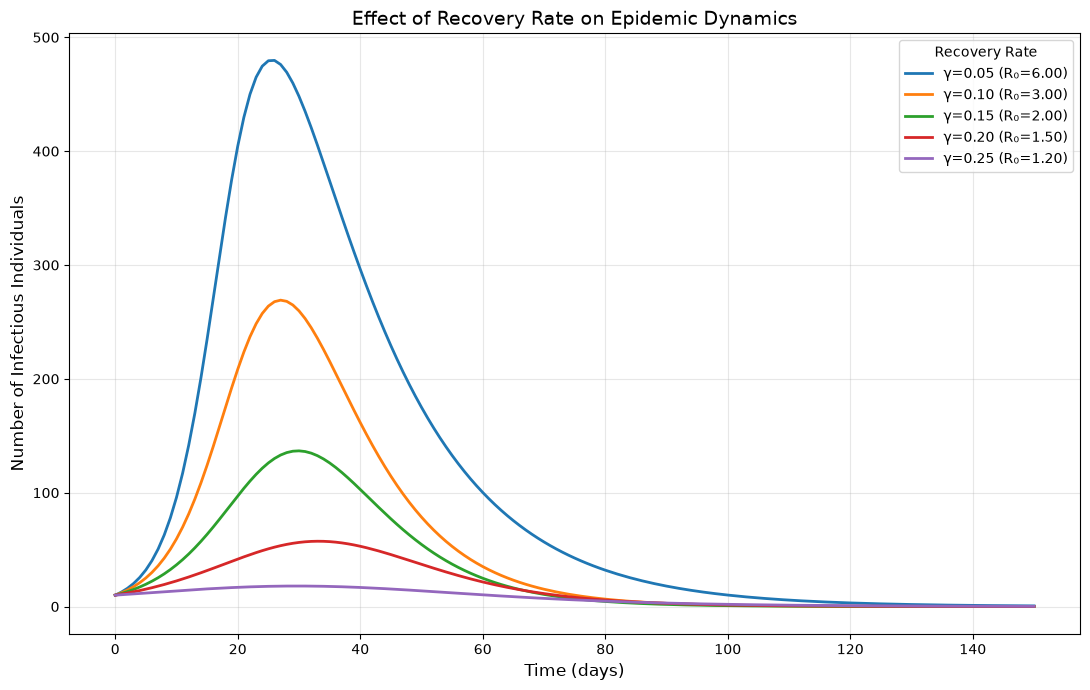

   gamma   R0  peak_infected  peak_day  total_deaths
0   0.05  6.0            480        26           165
1   0.10  3.0            269        27            84
2   0.15  2.0            137        30            48
3   0.20  1.5             57        33            26
4   0.25  1.2             18        30            11


In [12]:
results = analyze_recovery_rates(beta=0.3,mu=0.01,N=1000,I0=10,simulation_days=151)
print (results)

Part 2: Scenario Comparison

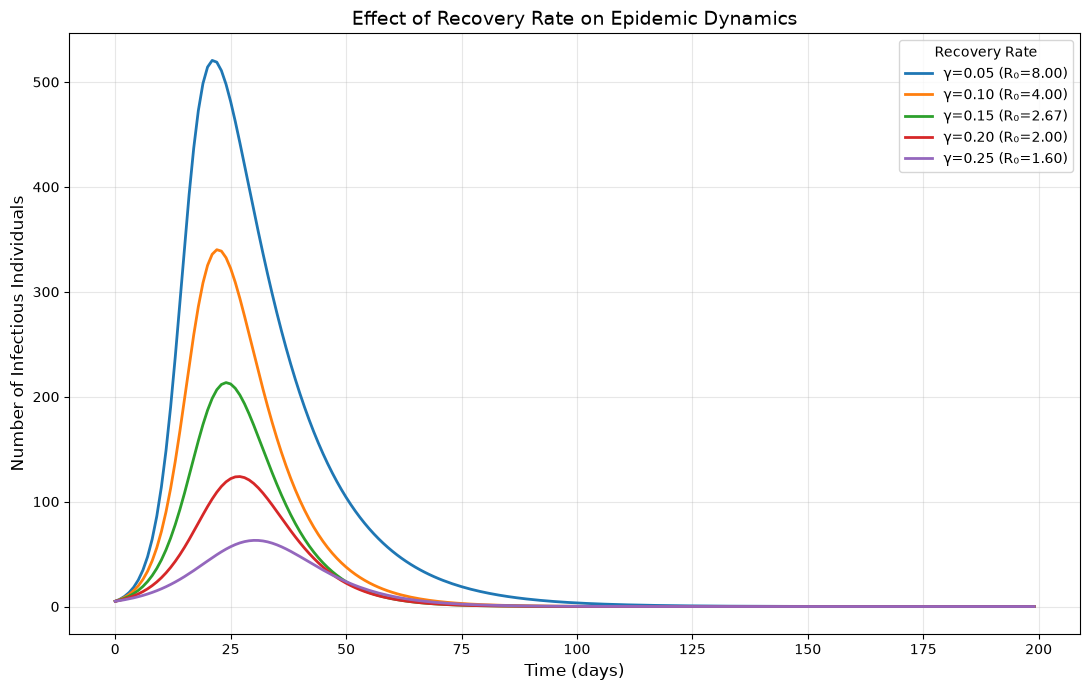

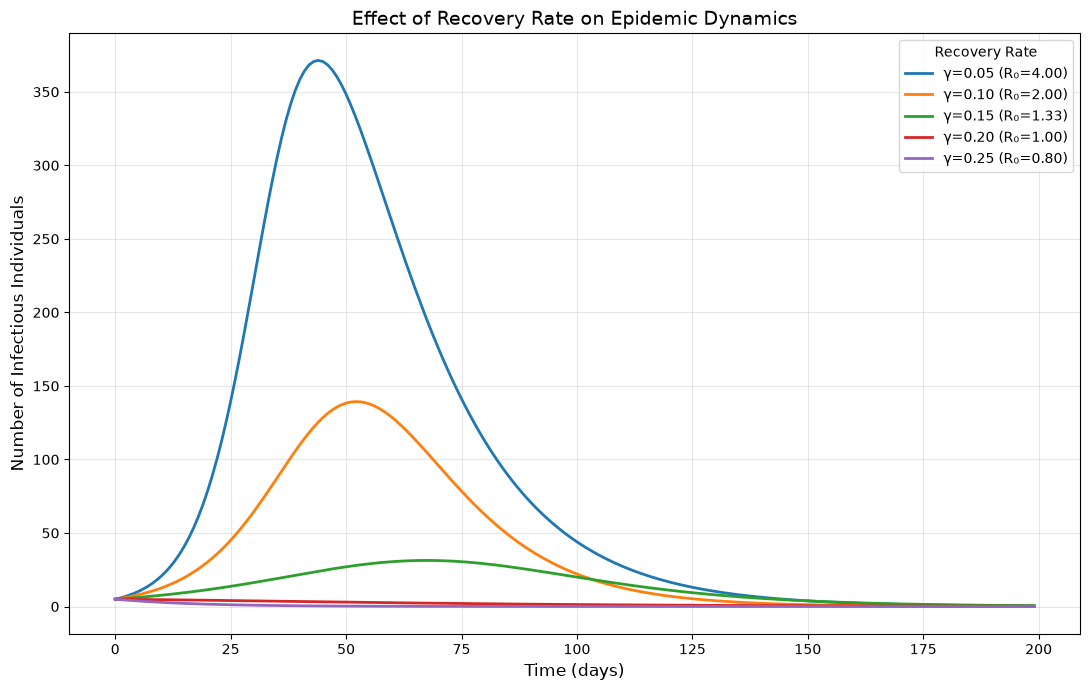

Scenario A — High Transmission


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,521,21,285
1,0.10,4.00,340,22,160
2,0.15,2.67,213,24,103
3,0.20,2.00,124,27,67
4,0.25,1.60,63,30,43


Scenario B — Low Transmission


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371,44,88
1,0.10,2.00,139,52,37
2,0.15,1.33,31,67,14
3,0.20,1.00,5,0,2
4,0.25,0.80,5,0,0


Combined Visualization


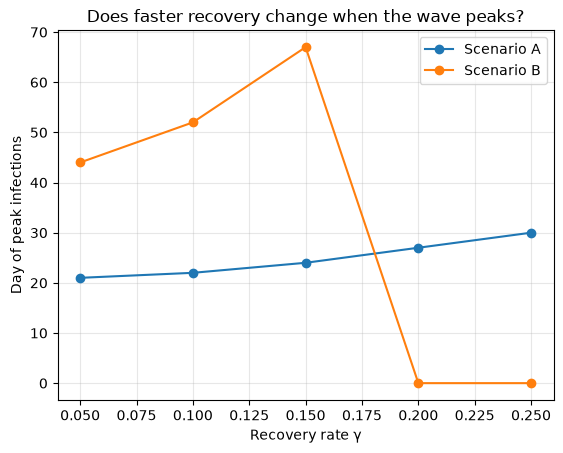

In [ ]:
scenario_A = dict(beta = 0.4, mu = 0.02, N = 1000, I0 = 5, simulation_days = 200) # High Tansmission
scenario_B = dict(beta = 0.2, mu = 0.005, N = 1000, I0 = 5, simulation_days = 200) # Low Transmission


results_A = analyze_recovery_rates(**scenario_A)
results_B = analyze_recovery_rates(**scenario_B)

print("Scenario A — High Transmission")
display(results_A.round(2))
print("Scenario B — Low Transmission")
display(results_B.round(2))

print("Combined Visualization")
plt.plot(results_A["gamma"], results_A["peak_day"], "o-", label="Scenario A")
plt.plot(results_B["gamma"], results_B["peak_day"], "o-", label="Scenario B")

plt.xlabel("Recovery rate γ")
plt.ylabel("Day of peak infections")
plt.title("Does faster recovery change wave peak timing?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


The "Does faster recovery change wave peak timing?" figure allows us to infer that a higher recovery rate significantly delays the timing of the wave peak in Scenario A (High Transmission), as well as Scenario B (Low Transmission). At a recovery rate of 0.2, the day of peak infections in Scenario B drops to 0, which means that at day 0 of the epidemic most of the transmissions are complete. The infected humans are so likely to either die or recover, that no other day in our 200 day simulation window has a higher infection count.

A later peak generally correlates with a flatter curve, as those who are recovered by then are outside of the "Susceptible" population. The flatter curve allows a healthcare sector to deal with the epidemic more efficiently, contributing to an increase in recovery rate, yielding a loop in further decreasing death count.
Following from this, the low tranmission Scenario B is the lesser damaging scenario in public health.

Part 3: Policy Recommendations

3.1 Parameter Impact Analysis

Looking at the first experiment an increase in the recovery rate reduces the peak number of infections greatly from 480 for gamma = 0,05 to 18 for gamma = 0,25. The total number of deaths also falls from 165 to 11, however the peak days sligthly increase (from 26 to 30), with the highest number of 33 days at gamma = 0,20.


3.2 Intervention Analysis

To examine a recovery rate increase of 50% we could look at the experiments and the change in deats from gamma = 0,10 and gamma = 0,15.

In the first experiment we see a fall in deaths from 84 to 48.
In Scenario A the fall in deaths is from 160 and 103.
In Scenario B the deaths change from 37 and 14.

Across all experiments we also see a significant drop in peak infections, however the length of the peak in days stays relatively the same. 

Looking deeper into Scenario A the fall in deaths from 160 to 103 represent a decrease of 35,6%. The peak infected fall from 340 to 213, decrease of 37,4%. The peak days go up very slightly from 22 to 24.


3.3 Real-World Applicaton

Anti-viral treatments plus quick and redily available at home testing could double the recovery rate. This could help provide earlier more effective treatments and move people out of the infected category at twice the rate. Using Scenario A as a baseline we compare gamma = 0,05 and 0,10 the total number of deats decreases from 285 to 160 (a fall of 43,9%). In a real world scenario this is already a really great result in terms of saving lives.

Conclusion

Working towards reducing the recovery rate by effective and quick use of medicine is a great way to fight a pandemic. An increase in the recovery rate of on 50% could still result in a reduction of deaths by half or even more as shown by our experiments. The amount of peak infections also decrease by about half, howver the recovery rate does not seem to have a signifficant effect on the lenght of the infection peak as long as R0 is larger than 1. However as soon as we get R0 <= 1, which can be done with a high recovery rate, the spread is no longer pandemic and the number of peak days becomes 0.